In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import rcParams
from pathlib import Path
import numpy as np

# 设置中文字体支持
import matplotlib.font_manager as fm
# 备选中文字体列表
chinese_fonts = [
    "SimHei",           # Windows
    "Heiti TC",         # macOS
    "WenQuanYi Micro Hei",  # Linux
    "Microsoft YaHei",  # 微软雅黑
    "Arial Unicode MS", # 备选
]

# 获取系统可用字体
available_fonts = {f.name for f in fm.fontManager.ttflist}

# 查找第一个可用的中文字体
for font in chinese_fonts:
    if font in available_fonts:
        plt.rcParams["font.family"] = font
        break

plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

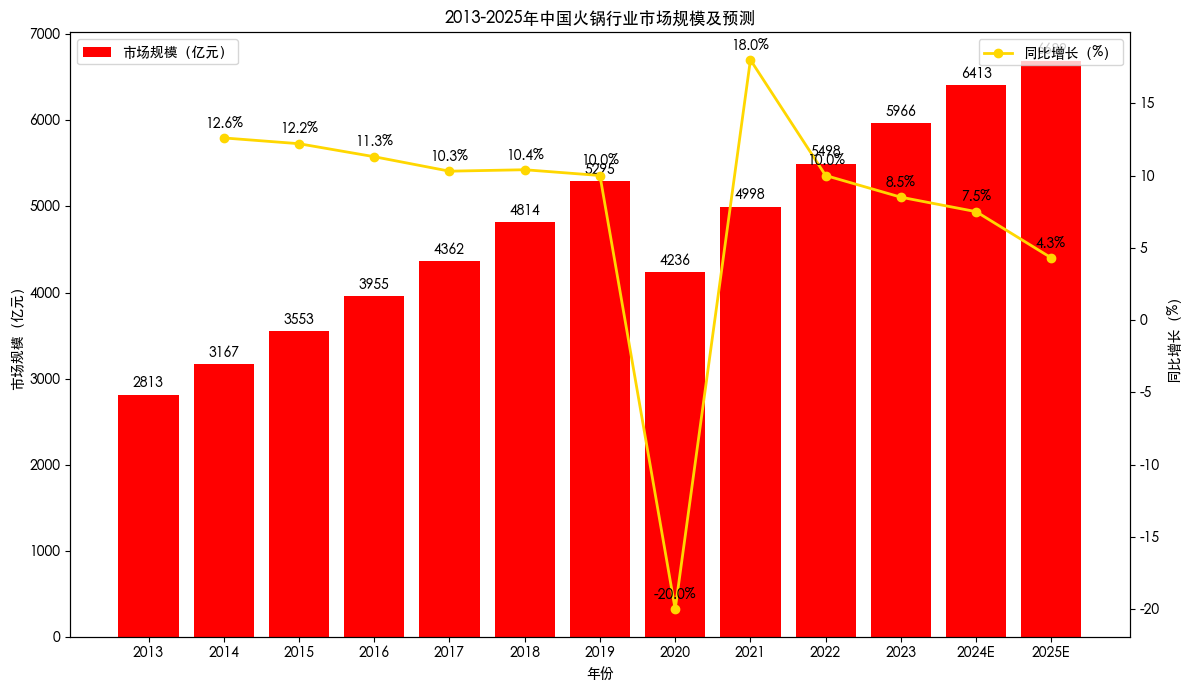

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
years = ["2013", "2014", "2015", "2016", "2017", "2018", "2019", "2020", "2021", "2022", "2023", "2024E", "2025E"]
market_size = [2813, 3167, 3553, 3955, 4362, 4814, 5295, 4236, 4998, 5498, 5966, 6413, 6689]
growth_rate = [np.nan, 12.6, 12.2, 11.3, 10.3, 10.4, 10.0, -20.0, 18.0, 10.0, 8.5, 7.5, 4.3]

x = np.arange(len(years))

fig, ax1 = plt.subplots(figsize=(12, 7))

# 绘制市场规模柱状图
ax1.bar(x, market_size, color='red', label='市场规模（亿元）')
ax1.set_ylabel('市场规模（亿元）')
ax1.set_xlabel('年份')
ax1.set_xticks(x)
ax1.set_xticklabels(years)
ax1.legend(loc='upper left')

# 创建双轴，绘制同比增长折线图
ax2 = ax1.twinx()
ax2.plot(x, growth_rate, marker='o', color='gold', label='同比增长（%）', linewidth=2)
ax2.set_ylabel('同比增长（%）')
ax2.legend(loc='upper right')

# 添加市场规模数值标注
for i, size in enumerate(market_size):
    ax1.text(i, size + 50, f'{size}', ha='center', va='bottom')

# 添加同比增长数值标注（跳过2013年，因无同比数据）
for i, rate in enumerate(growth_rate):
    if i > 0:
        ax2.text(i, rate + 0.5, f'{rate}%', ha='center', va='bottom')

ax1.set_title('2013-2025年中国火锅行业市场规模及预测')

plt.tight_layout()
plt.show()

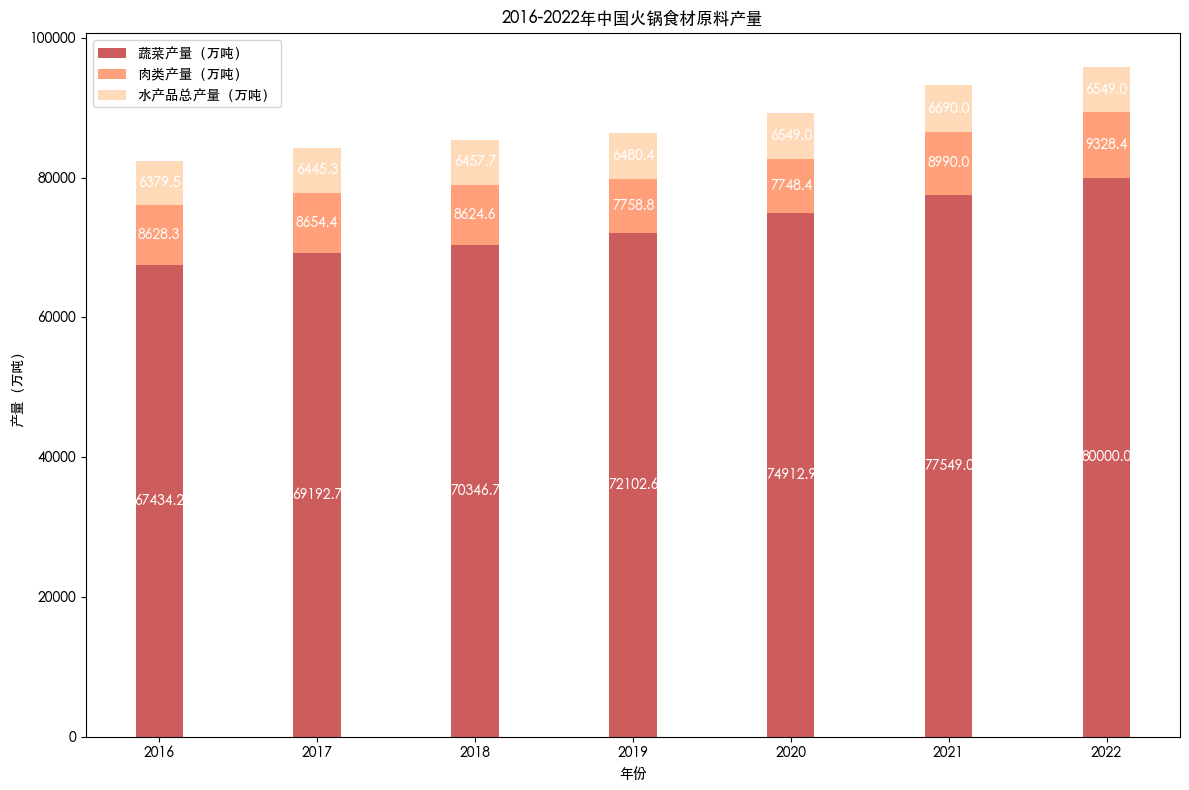

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 年份
years = ["2016", "2017", "2018", "2019", "2020", "2021", "2022"]
# 各类产量数据（单位：万吨），顺序：蔬菜、肉类、水产品
vegetable = [67434.2, 69192.7, 70346.7, 72102.6, 74912.9, 77549.0, 80000.0]
meat = [8628.3, 8654.4, 8624.6, 7758.8, 7748.4, 8990.0, 9328.4]
aquatic = [6379.5, 6445.3, 6457.7, 6480.4, 6549.0, 6690.0, 6549.0]

x = np.arange(len(years))  # x 轴坐标
bar_width = 0.3  # 每个类别柱状图宽度

fig, ax = plt.subplots(figsize=(12, 8))

# 绘制蔬菜产量柱状图（最底部）
ax.bar(x, vegetable, width=bar_width, label='蔬菜产量（万吨）', color='#CD5C5C')
# 绘制肉类产量柱状图（在蔬菜产量之上）
ax.bar(x, meat, width=bar_width, bottom=vegetable, label='肉类产量（万吨）', color='#FFA07A')
# 绘制水产品产量柱状图（在肉类产量之上）
ax.bar(x, aquatic, width=bar_width, bottom=np.array(vegetable) + np.array(meat), 
       label='水产品总产量（万吨）', color='#FFDAB9')

# 添加各类产量数值标注
# 标注蔬菜产量
for i, v in enumerate(vegetable):
    ax.text(i, v / 2, f'{v}', ha='center', va='center', color='white', fontweight='bold')
# 标注肉类产量
for i, (v, m) in enumerate(zip(vegetable, meat)):
    ax.text(i, v + m / 2, f'{m}', ha='center', va='center', color='white', fontweight='bold')
# 标注水产品产量
for i, (v, m, a) in enumerate(zip(vegetable, meat, aquatic)):
    bottom_sum = v + m
    ax.text(i, bottom_sum + a / 2, f'{a}', ha='center', va='center', color='white', fontweight='bold')

ax.set_ylabel('产量（万吨）')
ax.set_xlabel('年份')
ax.set_xticks(x)
ax.set_xticklabels(years)
ax.legend()
ax.set_title('2016-2022年中国火锅食材原料产量')

plt.tight_layout()
plt.show()

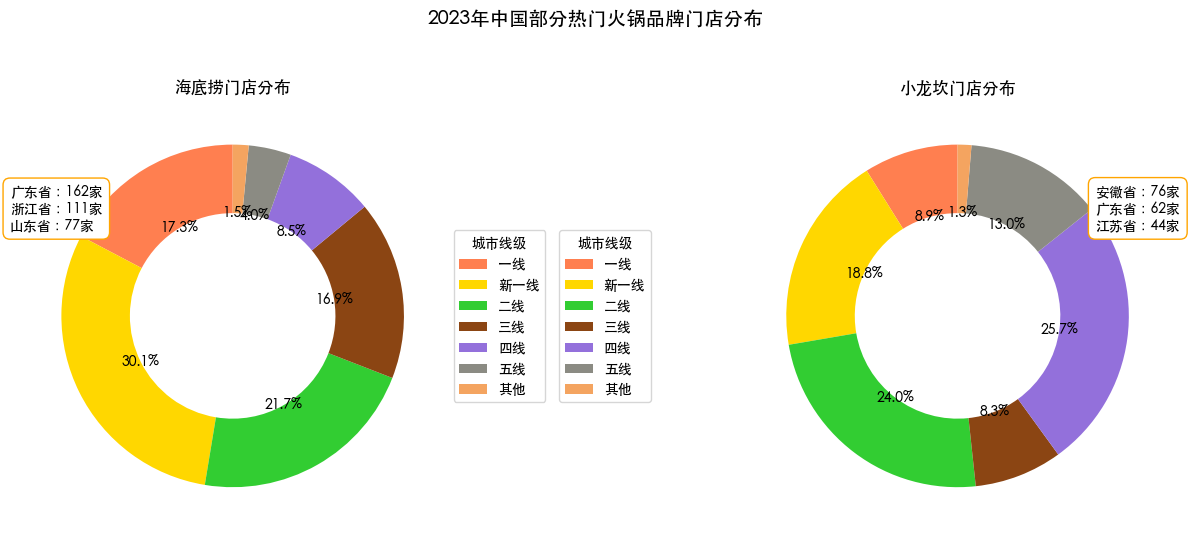

In [4]:
import matplotlib.pyplot as plt

# 海底捞数据
haidilao_labels = ["一线", "新一线", "二线", "三线", "四线", "五线", "其他"]
haidilao_sizes = [17.3, 30.1, 21.7, 16.9, 8.5, 4.0, 1.5]
haidilao_provinces = {"广东省": 162, "浙江省": 111, "山东省": 77}
haidilao_colors = ["#FF7F50", "#FFD700", "#32CD32", "#8B4513", "#9370DB", "#8B8B83", "#F4A460"]

# 小龙坎数据
xiaolongkan_labels = ["一线", "新一线", "二线", "三线", "四线", "五线", "其他"]
xiaolongkan_sizes = [8.9, 18.8, 24.0, 8.3, 25.7, 13.0, 1.3]
xiaolongkan_provinces = {"安徽省": 76, "广东省": 62, "江苏省": 44}
xiaolongkan_colors = ["#FF7F50", "#FFD700", "#32CD32", "#8B4513", "#9370DB", "#8B8B83", "#F4A460"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 绘制海底捞环形饼图
wedges, texts, autotexts = ax1.pie(haidilao_sizes, colors=haidilao_colors, autopct='%1.1f%%', startangle=90,
                                    wedgeprops=dict(width=0.4))
ax1.set_title('海底捞门店分布')
# 绘制省份文本框
province_text = "\n".join([f"{province}：{count}家" for province, count in haidilao_provinces.items()])
ax1.text(-1.3, 0.5, province_text, fontsize=10, bbox=dict(facecolor='white', edgecolor='orange', boxstyle='round,pad=0.5'))
# 调整图例，放在饼图右侧
ax1.legend(wedges, haidilao_labels, title="城市线级", loc="center left", bbox_to_anchor=(1, 0.5))
# 让标注文字颜色更清晰（区分深色/浅色切片）
for autotext in autotexts:
    autotext.set_color('black' if autotext.get_position()[1] > 0.5 else 'black')

# 绘制小龙坎环形饼图
wedges2, texts2, autotexts2 = ax2.pie(xiaolongkan_sizes, colors=xiaolongkan_colors, autopct='%1.1f%%', startangle=90,
                                      wedgeprops=dict(width=0.4))
ax2.set_title('小龙坎门店分布')
# 绘制省份文本框
province_text2 = "\n".join([f"{province}：{count}家" for province, count in xiaolongkan_provinces.items()])
ax2.text(1.3, 0.5, province_text2, fontsize=10, ha='right',
         bbox=dict(facecolor='white', edgecolor='orange', boxstyle='round,pad=0.5'))
ax2.legend(wedges2, xiaolongkan_labels, title="城市线级", loc="center right", bbox_to_anchor=(-0.2, 0.5))
for autotext in autotexts2:
    autotext.set_color('black' if autotext.get_position()[1] > 0.5 else 'black')

plt.suptitle('2023年中国部分热门火锅品牌门店分布', fontsize=14)
plt.tight_layout()
plt.show()